# HawkesNest — Quickstart

Two paths: **recipe mode** (validated suites) and **custom DGP mode**
(compose your own simulator config).  This notebook uses recipe mode
to generate a tiny sample from each validated suite, then shows the
three diagnostic views in the recommended visual hierarchy:

1. **KDE density** — smooth spatial distribution (primary)
2. **2D event scatter** — coloured by time (secondary)
3. **3D (x, y, t) cloud** — temporal structure (tertiary)


In [1]:
from hawkesnest.suites import EntanglementSuite, HeterogeneitySuite
from hawkesnest.viz import plot_kde_panels, plot_events_2d, plot_events_3d
import matplotlib.pyplot as plt

ent_results = {
    level: EntanglementSuite().generate(level=level, n_events=300, seed=0)
    for level in ("L0", "L2")
}
het_results = {
    level: HeterogeneitySuite().generate(level=level, n_events=300, seed=0)
    for level in ("H0", "H3")
}
print("generated:", {k: v.n_events for k,v in {**ent_results,**het_results}.items()})
ent_results["L2"].events.head()


generated: {'L0': 300, 'L2': 300, 'H0': 300, 'H3': 300}


,t,x,y,m,is_triggered
0,0.002089,0.269787,0.040974,1,False
1,0.005870,0.935072,0.815854,1,True
2,0.063095,0.796324,0.230642,1,True
3,0.151694,0.732006,0.614373,1,True
4,0.452222,0.937905,0.094777,1,True


## Primary view — smooth KDE density

KDE contour fills show the spatial density of event locations without scatter artefacts. Left: separable baseline (L0). Right: heterogeneous Gabor background (H3).

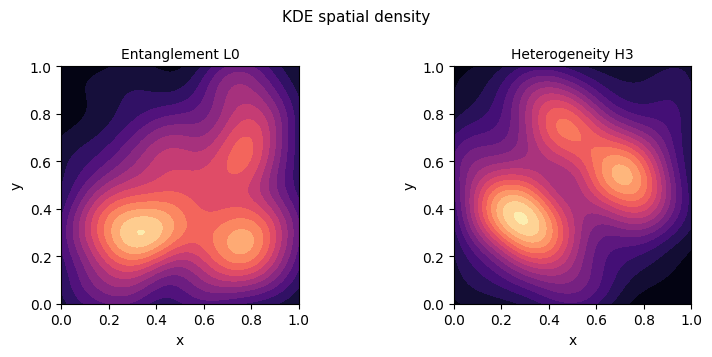

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))

for ax, (label, result) in zip(axes, [("Entanglement L0", ent_results["L0"]),
                                       ("Heterogeneity H3", het_results["H3"])]):
    from hawkesnest.viz.suites import plot_kde_panels
    import numpy as np
    from scipy.stats import gaussian_kde
    df = result.events
    xs, ys = df["x"].to_numpy(), df["y"].to_numpy()
    X, Y = np.mgrid[0:1:80j, 0:1:80j]
    Z = gaussian_kde(np.vstack([xs, ys]))(np.vstack([X.ravel(), Y.ravel()])).reshape(80, 80)
    ax.contourf(X, Y, Z, levels=14, cmap="magma")
    ax.set_aspect("equal"); ax.set_title(label, fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y")

fig.suptitle("KDE spatial density", fontsize=11)
fig.tight_layout()
plt.show()


## Secondary view — 2D event scatter coloured by time

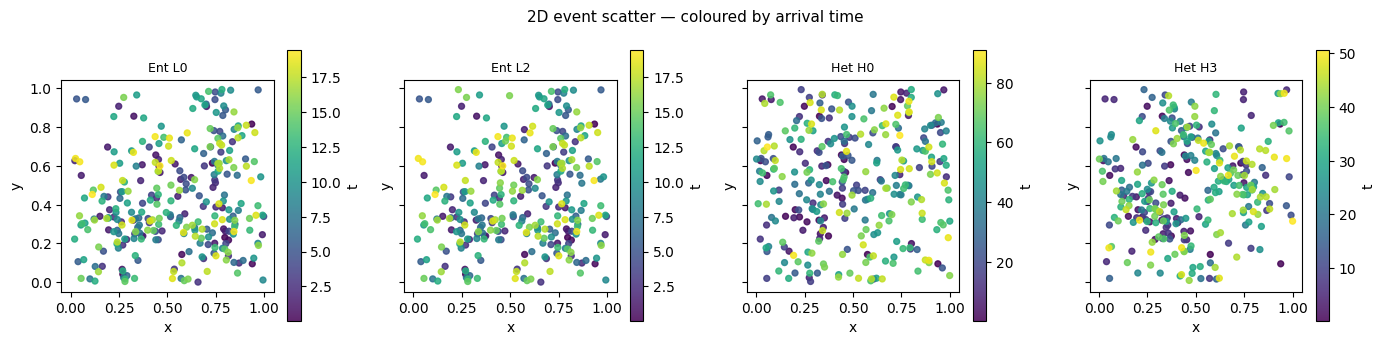

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), sharex=True, sharey=True)
for ax, (label, result) in zip(axes, [
    ("Ent L0", ent_results["L0"]), ("Ent L2", ent_results["L2"]),
    ("Het H0", het_results["H0"]), ("Het H3", het_results["H3"]),
]):
    plot_events_2d(result.events, ax=ax, color_by="t", cmap="viridis")
    ax.set_title(label, fontsize=9)
fig.suptitle("2D event scatter — coloured by arrival time", fontsize=11)
fig.tight_layout()
plt.show()


## Tertiary view — 3D (x, y, t) event cloud

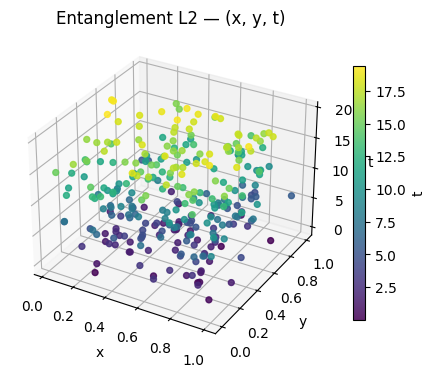

In [4]:
fig, ax = plot_events_3d(ent_results["L2"].events, color_by="t",
                         title="Entanglement L2 — (x, y, t)")
plt.show()
